**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v4 =  Analysis 2 (filtered GCC data) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/30/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/25/2025
* Finished Iteration on -06/30/2025-

In [51]:
# Run once for pip installs and upgrades
#%pip install --upgrade pip


In [52]:
# Import and load libs and packages
import pandas as pd
import seaborn as sns
import re
import glob
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from rapidfuzz import process, fuzz

# Download NLTK stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rford\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [53]:
# Load base dataset here
df = pd.read_excel("City and County Raw Personnel Data/2024_City.xlsx")

# Split into training (30%) and test (70%)
train_df = df.sample(frac=0.3, random_state=42)
test_df = df.drop(train_df.index)

In [54]:
# Keywords to KEEP
keep_dept_keywords = [
    "Planning", "Community Development", "Building Department", "Code Compliance",
    "Public Works", "Streets", "Engineering", "Construction", "Zoning"
]

keep_position_keywords = [
    "Construction", "Building", "HVAC", "Plans Inspector", "Zoning Investigator",
    "Architect", "Permit Technician", "Safety Inspector", "Planner", "Code Enforcer",
    "Plan Check Coordinator", "Licensing Specialist", "Community Development Technician"
]

# Keywords to FILTER OUT
filter_dept_keywords = [
    "Administration", "Communications", "Animal", "Finance", "Community Services",
    "Municipal Power", "Base Reuse", "City Attorney", "City Clerk", "Council", "Fire",
    "Human Resources", "Library", "IT", "Police", "Recreation", "Government Services",
    "Facilities", "Water", "Power", "Airport", "Health", "Zero Waste", "Sewer",
    "Equipment", "Transfer Station", "Janitor", "Landscaping", "Utilities", "Business",
    "Transit", "Nutrition", "Aging", "Adult", "Youth", "Homeless", "Athletics", "Law",
    "Attorney", "Management","Public Works - Sanitation","Public Works - Street Services",
    "Public Works - Maint Svcs","Streets","Public Works-Operations","Public Works - Parks And Landscape ",
    "Public Works - Streets","Public Works-Corporate Yard","Public Works - Maintenance",
    "Public Works - Parks","Public Works Operations","Public Works - Refuse","Public Works/Solid Waste",
    "Public Works - Solid Waste","Public Works - Wastewater","Public Works/Street Maintenance",
    "War Memorial","Public Works - Right Of Way","Public Works - Utility Services", "Street Maintenance",
    "Public Works Parks","Grounds Maintenance","Public Works Yard",
    
]

filter_position_keywords = [
    "Motor Sweeper Operator","Public Works Ranger","Park Ranger","Administrative Assistant","Fitness instructor",
    "Administrative Intern","Equipment Operator","Crossing Guard","Park Lead","Plumber","Mechanic","Gardener",
    "Temporary","Chemist","Seasonal Aide","Plant Operator","Foreman Water","Solid Resources","Parks","Asphalt Worker",
    "Business Analyst","Human Resources","Parking","Facilities","Golf","Downtown","Stationary","Groundskeeper"
    "Laboratory Technician", "Building & Grounds Patrol Officer", "Patrol Officer", "Youth Job Corps Program Participant",
    "School Guard","Tree Trimmer", "Transit Coach Operator","General Laborer", "Street Inspector","Utility Worker","Custodial",
    "Office Specialist","Street Services","Maintenance","Accountant","City Worker","Sanitation","Graffiti"
    "Maintenance Supervisor","Wastewater Treatment Operator","Wastewater Treatment Mechanic","Office Assistant",
    "Recreational Leader", "Librarian", "Admin", "Clerk","Wastewater System Operator","Water Foreman",
    "Wastewater Conveyance Operator","Management Assistant","Street Maintenance Worker","Maintenance Aide",
    "Lot Operator","Public Works Maintenance Worker","Maintenance Worker","Project Assistant","Project Manager",
    "Tree Surgeon","Intern","Truck Driver","Solid Waste Equipment Operator","Refuse Operator","Refuse Collection Supervisor",
    "Secretary", "Parking Officer", "Police", "Firefighter", "Treasurer", "Employment Worker",
    "Lifeguard", "Animal", "Recycling","Management Analyst", "Sewer", "Finance", "HR", "IT", "Parks & Rec",
    "Health", "EMT", "Custodian","Maintenance Worker", "Equipment Mechanic", "Aquatics", "Traffic",
    "Community Service", "Veterinary", "Senior Citizen", "Pool", "Utilities", "Audio","Irrigation Specialist",
    "Communications", "Mayor", "Attendant", "Vocational Worker", "Messenger Clerk","Staff Assistant",
    "Customer Service", "Truck Operator", "Sanitation", "Painter","Water Utility Worker","Arborist"
    "Laborer","Public Works Laborer", "Program Assistant","Staff Specialist","Refuse","Department Assistant","Landscape"
]


In [55]:
# Helper function to match keywords
def keyword_match(text, keywords):
    if pd.isna(text):
        return False
    return any(re.search(rf'\b{re.escape(k)}\b', str(text), re.IGNORECASE) for k in keywords)

# Label rows for training
def label_row(row):
    keep_dept = keyword_match(row['DepartmentOrSubdivision'], keep_dept_keywords)
    keep_pos = keyword_match(row['Position'], keep_position_keywords)
    filter_dept = keyword_match(row['DepartmentOrSubdivision'], filter_dept_keywords)
    filter_pos = keyword_match(row['Position'], filter_position_keywords)
    return int((keep_dept or keep_pos) and not (filter_dept or filter_pos))


In [56]:
# Apply labeling
train_df["label"] = train_df.apply(label_row, axis=1)

# Combine text for model training
train_df["combined_text"] = train_df["DepartmentOrSubdivision"].fillna('') + " " + train_df["Position"].fillna('')

# Show label distribution
train_df["label"].value_counts()


label
0    93755
1     6523
Name: count, dtype: int64

In [57]:
# Feature and Target Preparation

X = train_df["combined_text"]
y = train_df["label"]


In [58]:
# Create pipeline with TF-IDF + Random Forest
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=stopwords.words('english'), max_features=1000)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
# Train model
model.fit(X, y)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [59]:
train_df.head()

,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,MaxPositionSalary,...,PensionFormula,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType,label,combined_text
19233,2024,City,Brea,Police Services,Police Officer,False,False,NaN,94709.0,121251.0,...,2.7% @ 57,https://www.cityofbrea.gov/330/Human-Resources,47900,2025-06-24,Orange,NaN,False,NaN,0,Police Services Police Officer
44266,2024,City,Downey,Fire Suppression,Fire Captain,False,False,NaN,114100.0,141351.0,...,3% @ 50,http://www.downeyca.org/our-city/departments/h...,111871,2025-06-24,Los Angeles,NaN,False,NaN,0,Fire Suppression Fire Captain
190362,2024,City,Pasadena,"Parks, Recreation & Community Services",Senior Lifeguard/Instructor - B Full Time,False,False,NaN,60881.0,65230.0,...,2.0% @ 62,http://cityofpasadena.net/HumanResources/,140631,2025-06-24,Los Angeles,NaN,False,NaN,0,"Parks, Recreation & Community Services Senior ..."
25241,2024,City,Carlsbad,Police Field Operations,Community Service Officer II,False,False,NaN,61479.0,74728.0,...,2%@62,https://www.carlsbadca.gov/departments/human-r...,116368,2025-06-24,San Diego,NaN,False,NaN,0,Police Field Operations Community Service Offi...
5022,2024,City,Anaheim,Police,Police Officer - Master Advanced,False,False,NaN,112486.0,143562.0,...,3% @50,https://anaheim.net/401/Human-Resources,341773,2025-06-24,Orange,NaN,True,NaN,0,Police Police Officer - Master Advanced


In [60]:
# Combine text columns
test_df["combined_text"] = test_df["DepartmentOrSubdivision"].fillna('') + " " + test_df["Position"].fillna('')

# Predict using the trained model
test_df["predicted_label"] = model.predict(test_df["combined_text"])

# Filter the results
filtered_test_df = test_df[test_df["predicted_label"] == 1]
filtered_train_df = train_df[train_df["label"] == 1]
filtered_df = pd.concat([filtered_train_df, filtered_test_df], ignore_index=True)


# Display summary
print(f"Filtered rows: {len(filtered_df)} / {len(df)}")
filtered_df.head()



Filtered rows: 21661 / 334261


,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,MaxPositionSalary,...,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType,label,combined_text,predicted_label
0,2024,City,Los Angeles,Los Angeles Housing,Rehabilitation Construction Specialist Ill,False,False,NaN,110727.0,161945.0,...,https://personnel.lacity.gov/,3835263,2025-06-24,Los Angeles,NaN,True,NaN,1.0,Los Angeles Housing Rehabilitation Constructio...,NaN
1,2024,City,San Clemente,Engineering,Construction Inspector,False,False,NaN,83638.0,101663.0,...,https://www.san-clemente.org/departments-servi...,62865,2025-06-24,Orange,NaN,False,NaN,1.0,Engineering Construction Inspector,NaN
2,2024,City,Industry,Planning,Commissioner,False,False,NaN,11060.0,11503.0,...,http://www.cityofindustry.org,431,2025-06-24,Los Angeles,NaN,False,NaN,1.0,Planning Commissioner,NaN
3,2024,City,Long Beach,Public Works,Civil Engineering Associate,False,False,NaN,95232.0,129334.0,...,http://www.longbeach.gov/hr/,462561,2025-06-24,Los Angeles,NaN,True,NaN,1.0,Public Works Civil Engineering Associate,NaN
4,2024,City,Pomona,DS - Planning,Deputy Development Services Director,False,False,NaN,163632.0,198972.0,...,https://www.pomonaca.gov/government/department...,153042,2025-06-24,Los Angeles,NaN,False,NaN,1.0,DS - Planning Deputy Development Services Dire...,NaN


In [61]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [62]:
# Cleaning function
def clean_name(name):
    name = str(name).strip().lower()
    return name.title() if name else ''

# Clean columns for joining
filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


In [63]:
# Filters: Empty if not needed

# Specify the city to exclude
excluded_cities = ["Los Angeles"]
# Specify the county to exclude
excluded_counties = ["Los Angeles"]


In [64]:
# Aggregate and filter 
agg_city_counts = filtered_df.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts = filtered_df.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

filtered_city = filtered_df[~filtered_df['clean_city_name'].isin(excluded_cities)]
filtered_county = filtered_df[~filtered_df['clean_county_name'].isin(excluded_counties)]

agg_city_counts_filtered = filtered_city.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts_filtered = filtered_county.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

# Check the aggregated personnel count for cities and counties
#agg_city_counts
#agg_city_counts_filtered
#agg_county_counts
#agg_county_counts_filtered
#filtered_city
#filtered_county



In [65]:
# Bin ranges
agg_city_counts['city_personnel_bin'] = pd.cut(
    agg_city_counts['personnel_count_city'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)

agg_county_counts['county_personnel_bin'] = pd.cut(
    agg_county_counts['personnel_count_county'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)


In [66]:
# Read Files and load data
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_-3971126187329447856/BOE_CityCounty.shp")
county_geo = gpd.read_file("California_County_Boundaries_and_Identifiers_Blue_Version_view_2716745428963682036/California_County_Boundaries_and_Identifiers.shp")


In [67]:
# City maps (full + filtered)
geo_city = ca_geo_df.copy()
geo_city['clean_name'] = geo_city['CITY'].apply(clean_name)
geo_city = geo_city.merge(
    agg_city_counts[['clean_city_name', 'personnel_count_city', 'city_personnel_bin']],
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

geo_city['has_data'] = ~geo_city['personnel_count_city'].isna()
geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)

# Merge all needed data
geo_city_filtered = ca_geo_df.copy()
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(clean_name)

geo_city_filtered = geo_city_filtered.merge(
    agg_city_counts_filtered,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill missing values for plotting
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)



In [68]:
# Merge with county_geo: Full
county_geo['clean_name'] = county_geo['CDT_NAME_S'].apply(clean_name)

geo_county = county_geo.merge(
    agg_county_counts[['clean_county_name', 'personnel_count_county', 'county_personnel_bin']],
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)

# Merge with county_geo: Filtered
geo_county_filtered = county_geo.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill missing personnel counts with 0
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)

In [69]:
# Checks for geomaps
#geo_city
#geo_city_filtered
#geo_county
#geo_county_filtered

In [70]:
# Defining plotting function

def plot_personnel_map(gdf, column, title, cmap='YlGnBu'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing data"}
    )
    legend = ax.get_legend()
    if legend:
        legend.set_title(title)

    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


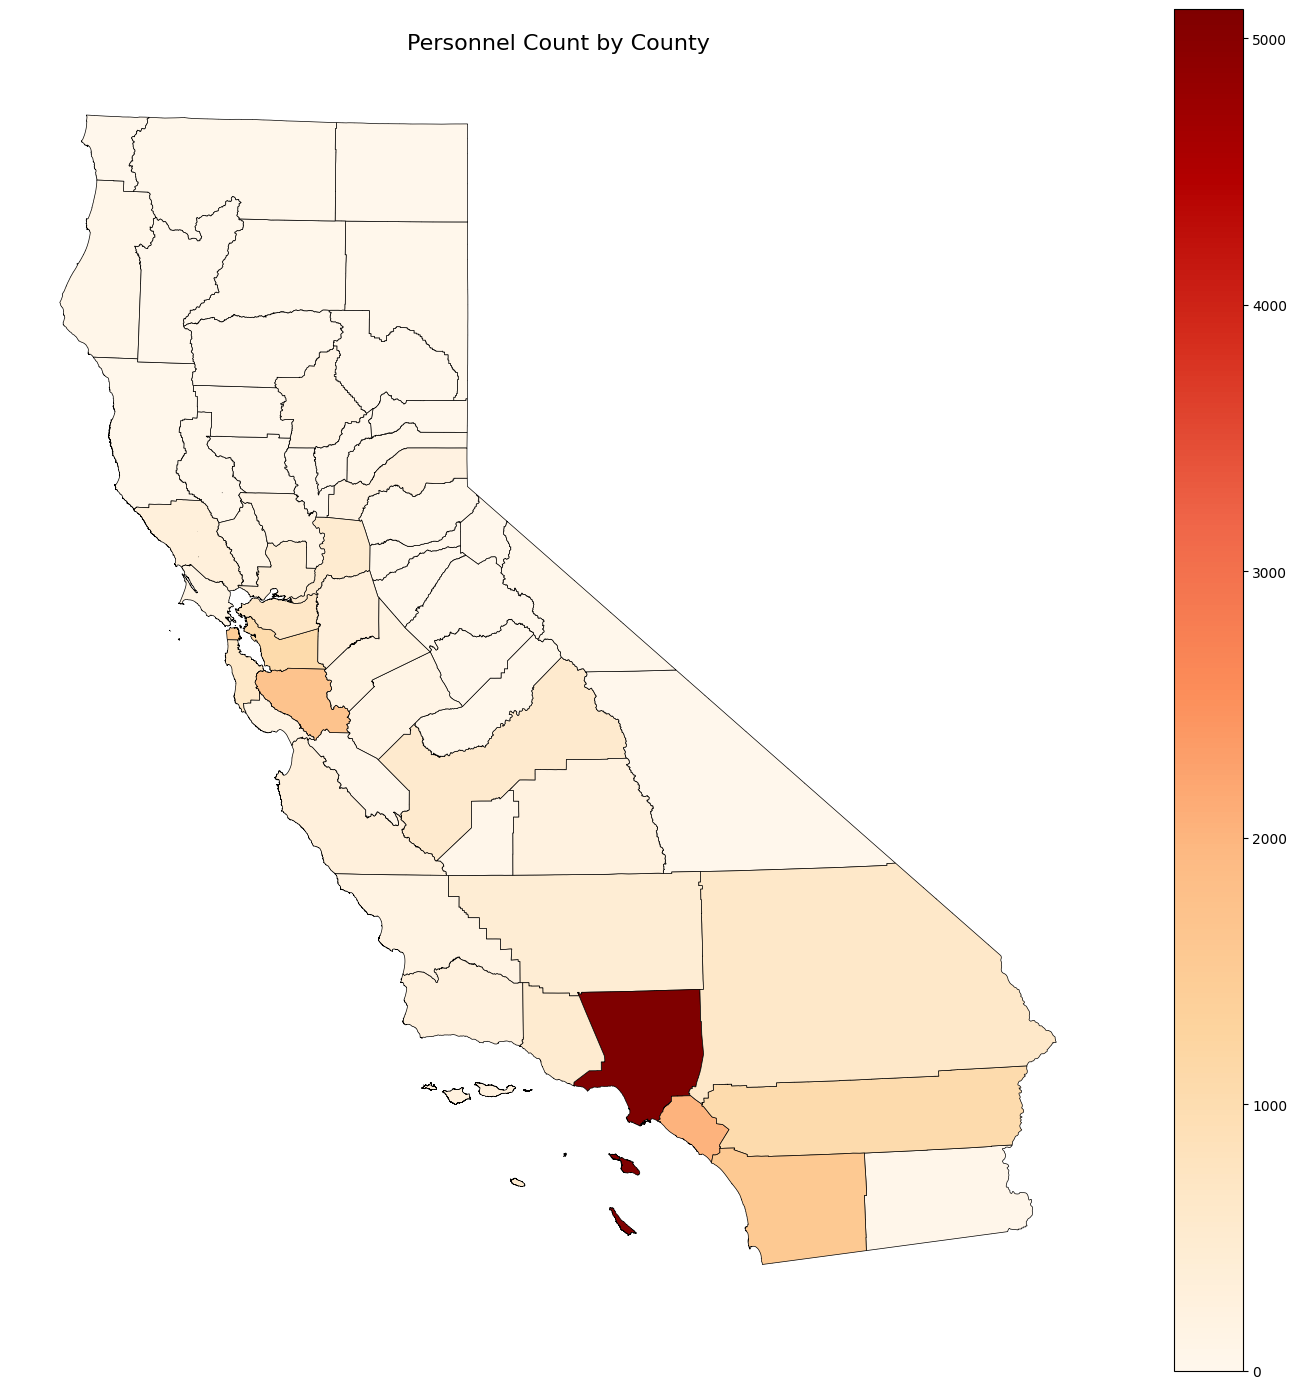

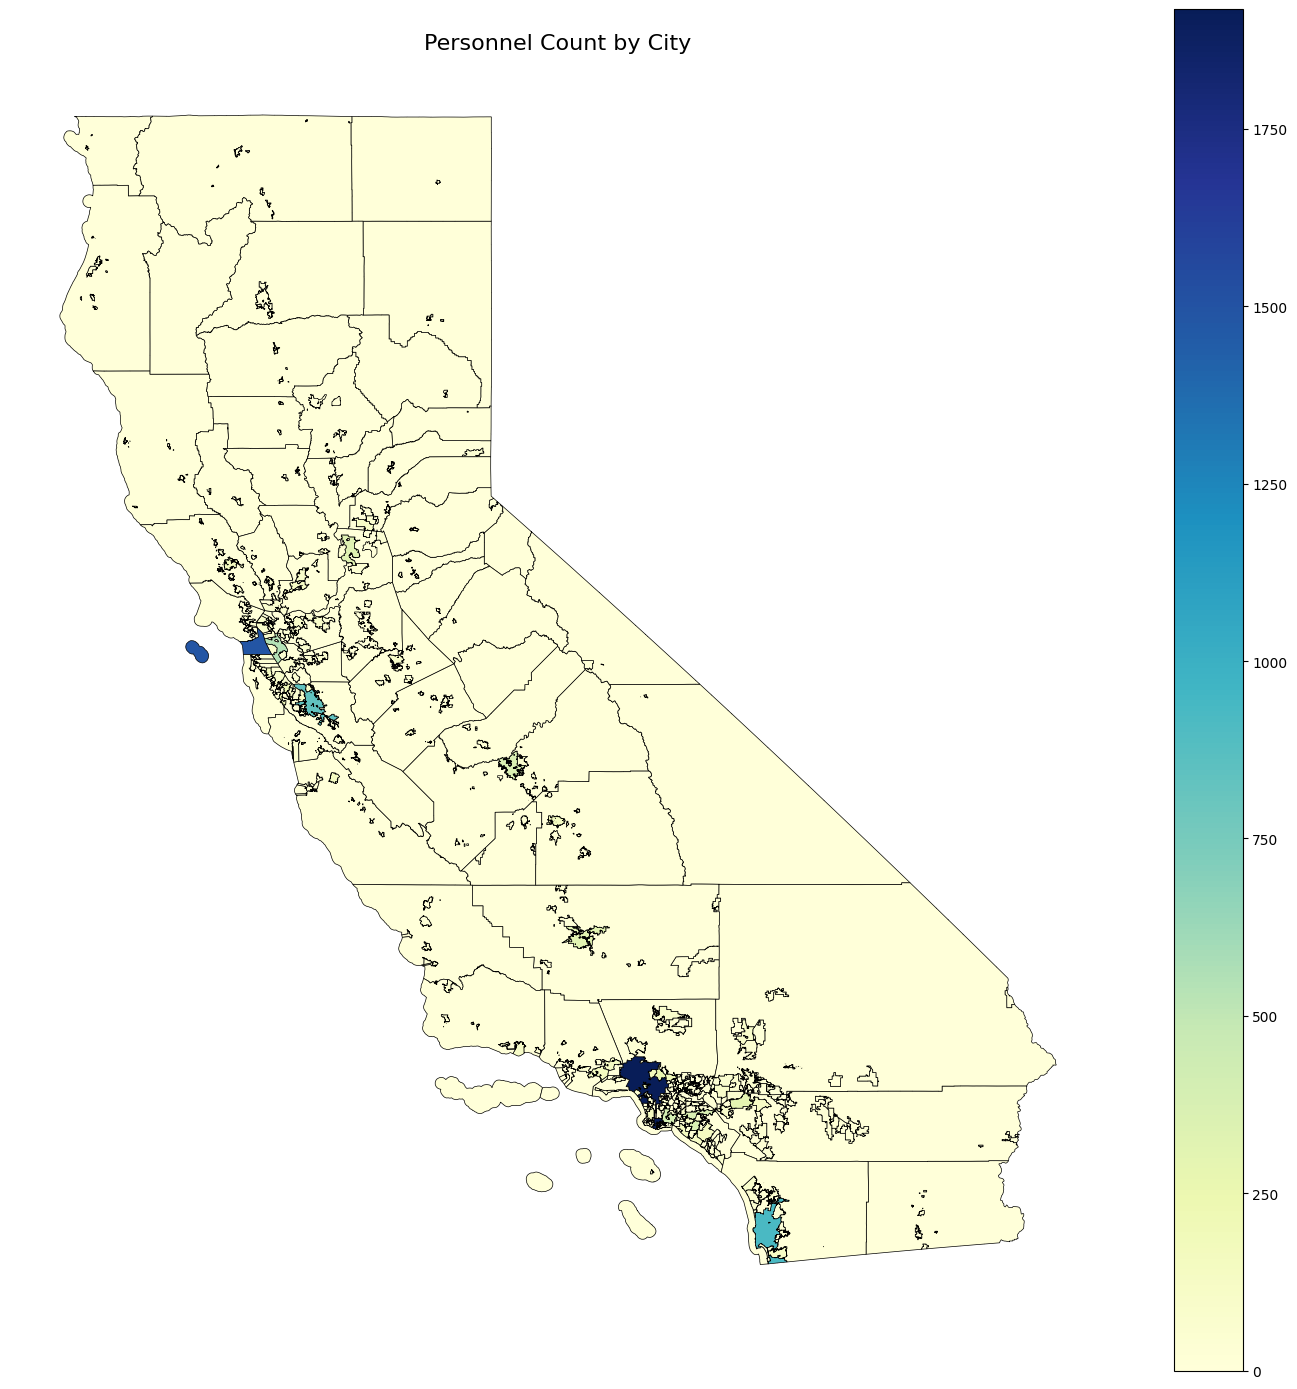

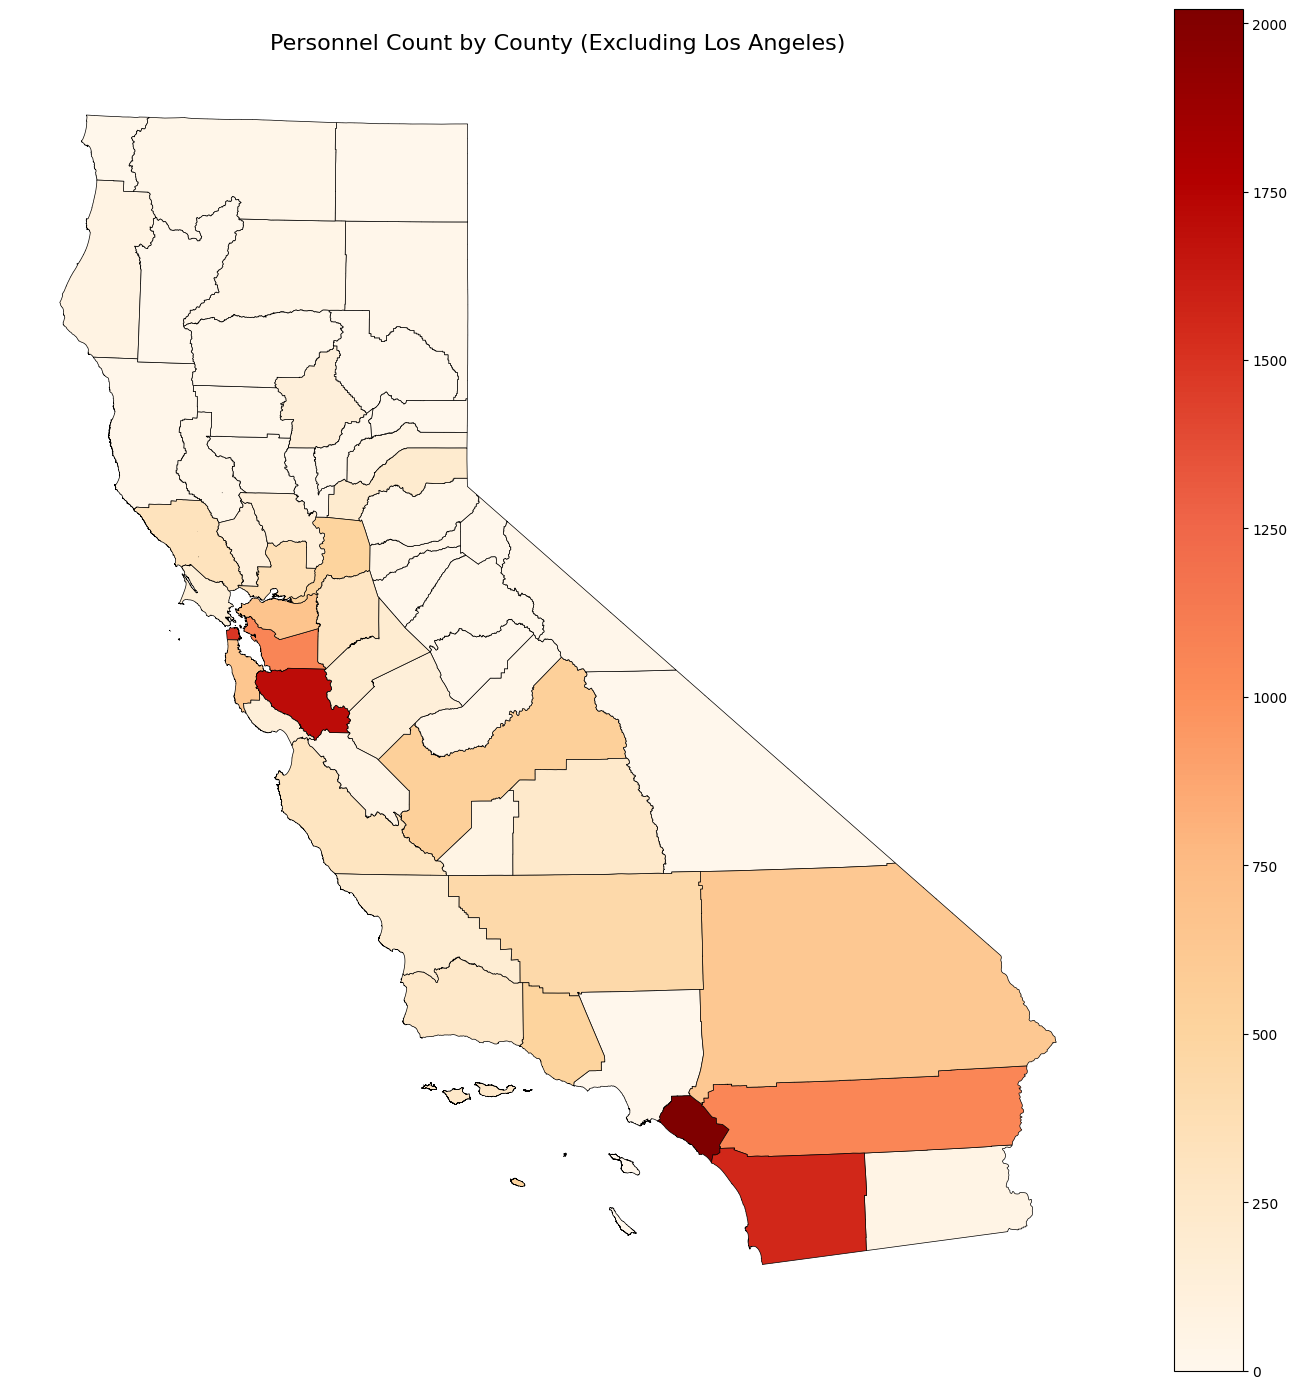

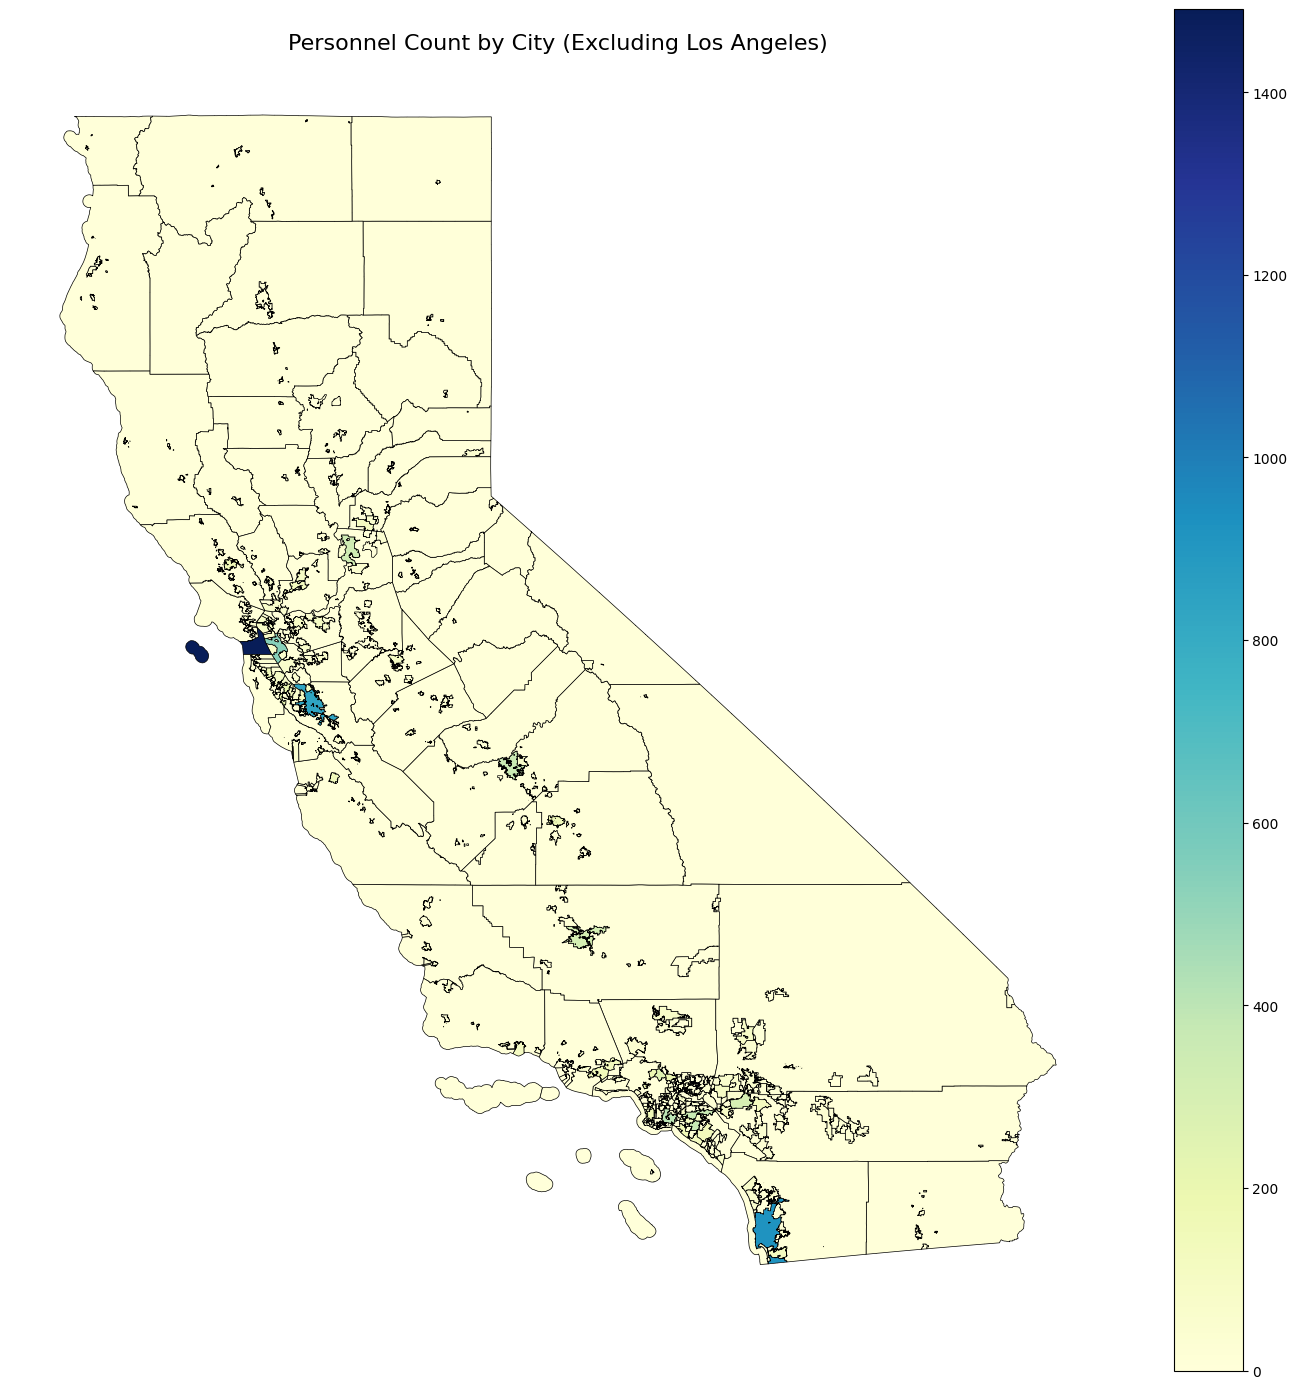

In [71]:
# Plot all maps

# County - All
plot_personnel_map(
    geo_county,
    column='personnel_count_county',
    title='Personnel Count by County',
    cmap='OrRd'
)

# City - All
plot_personnel_map(
    geo_city,
    column='personnel_count_city',
    title='Personnel Count by City',
    cmap='YlGnBu'
)

# County - Excluding Los Angeles
plot_personnel_map(
    geo_county_filtered,
    column='personnel_count_county',
    title = f"Personnel Count by County (Excluding {', '.join(excluded_counties)})",
    cmap='OrRd'
)

# City - Excluding Los Angeles
plot_personnel_map(
    geo_city_filtered,
    column='personnel_count_city',
    title = f"Personnel Count by City (Excluding {', '.join(excluded_cities)})",
    cmap='YlGnBu'
)



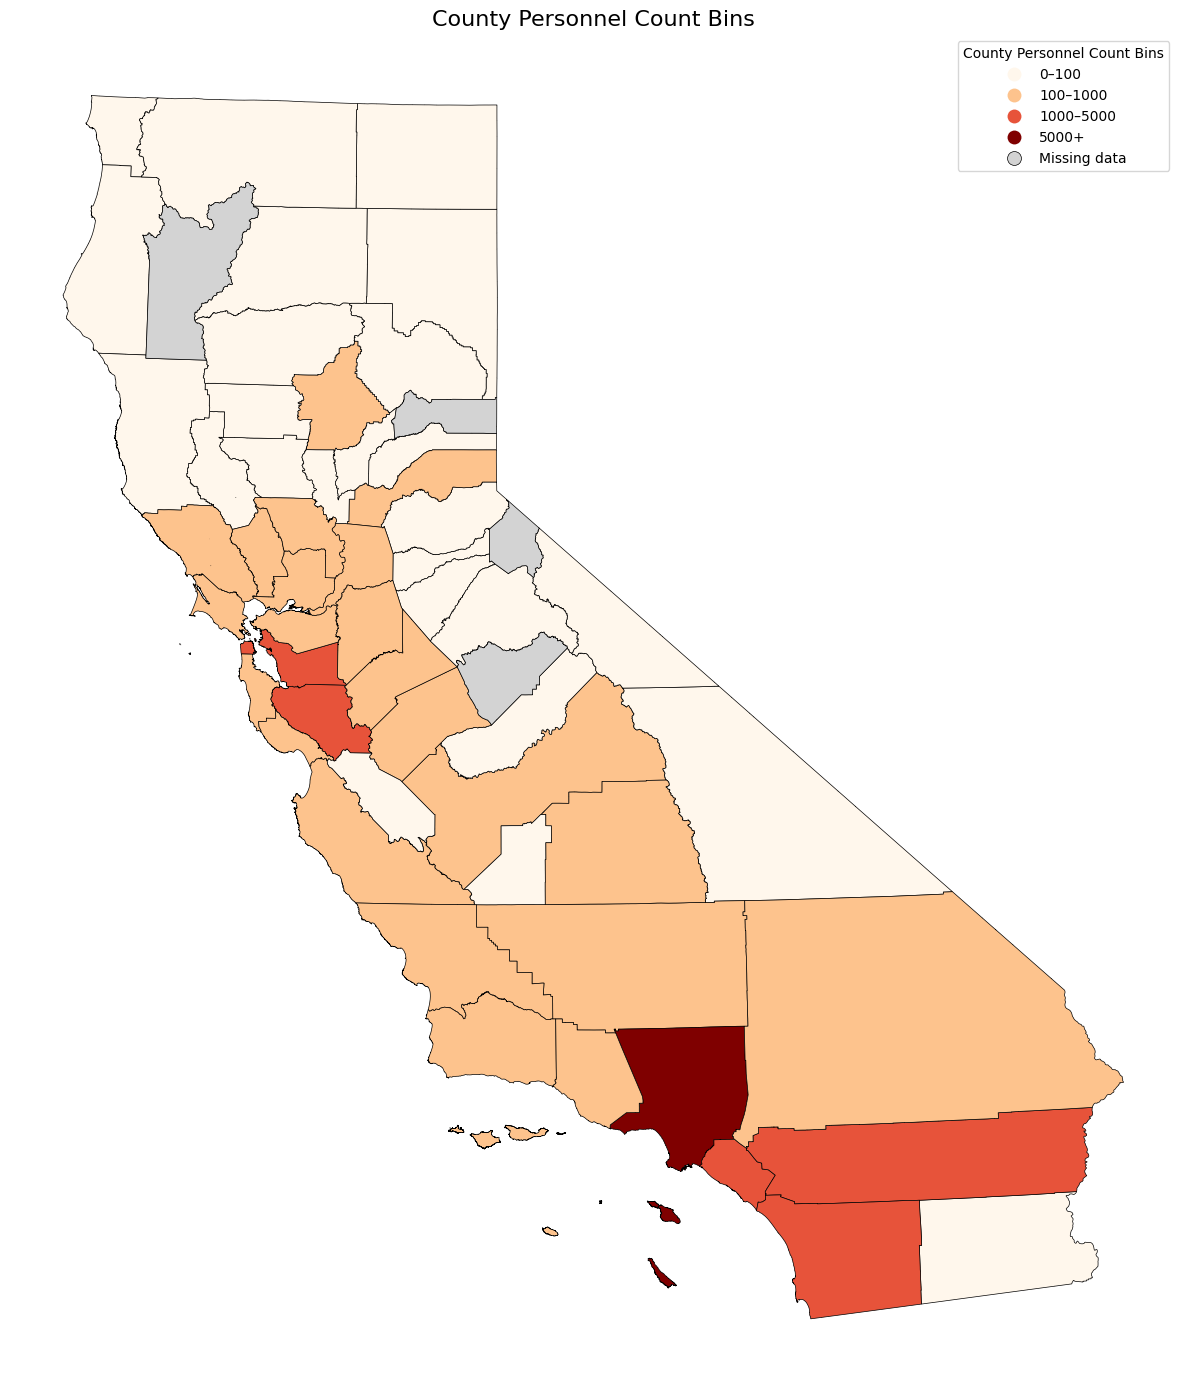

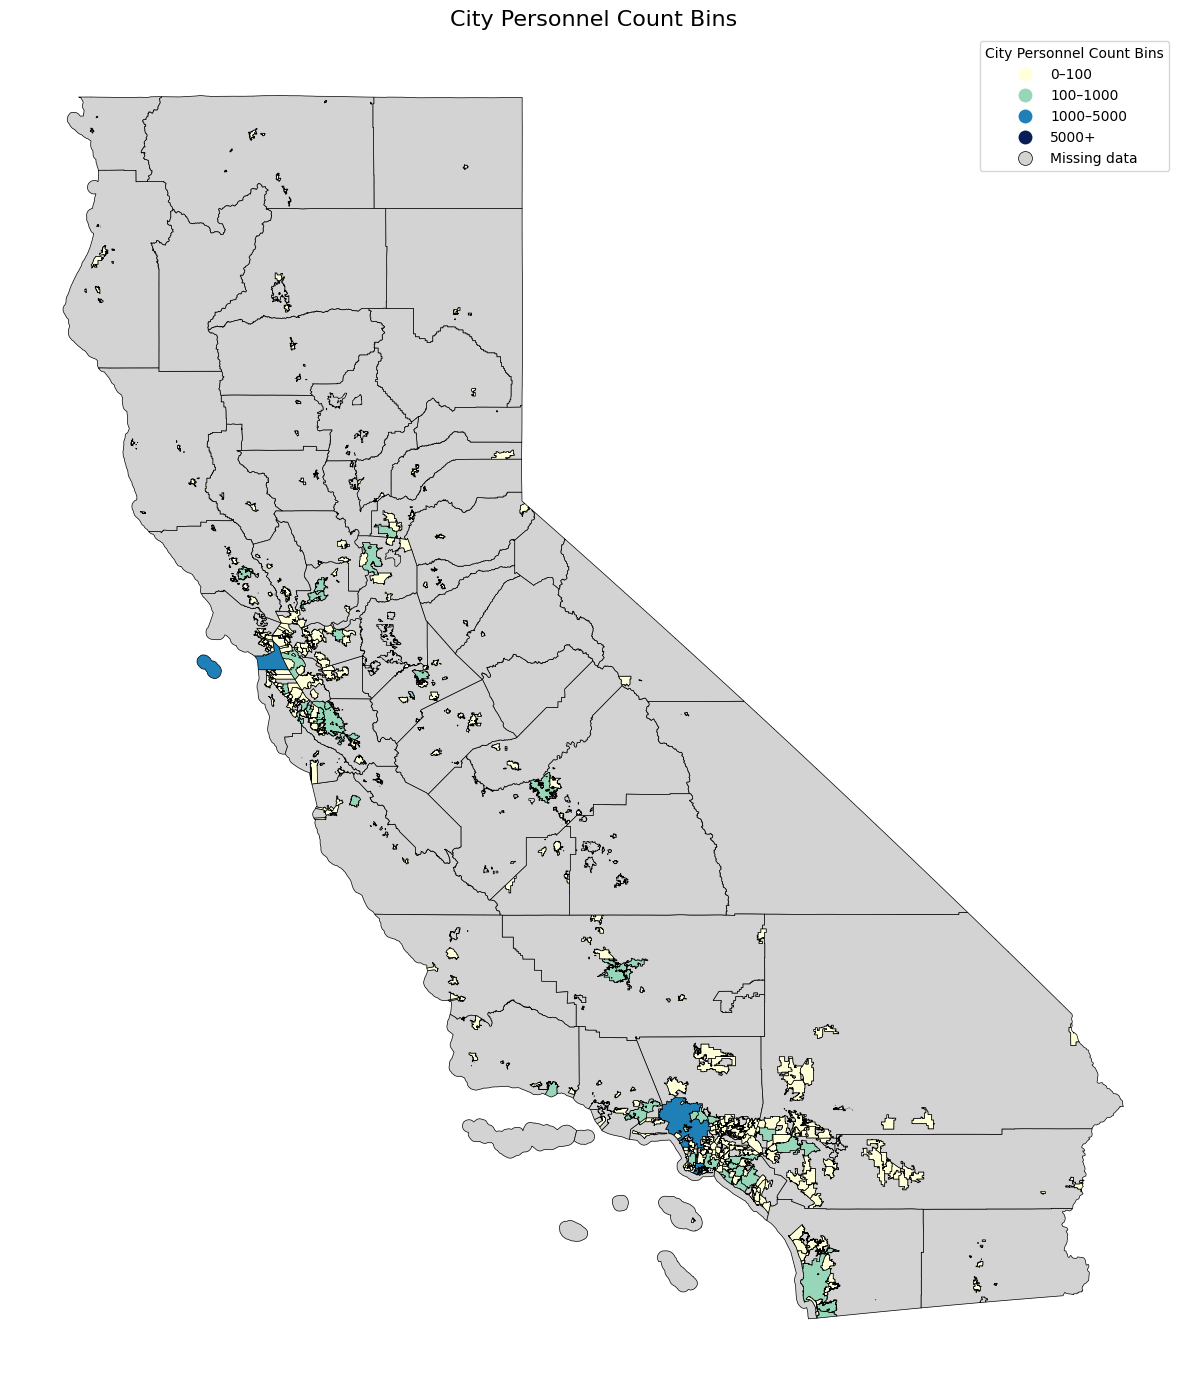

In [72]:
#  County Bins
plot_personnel_map(
    geo_county,
    column='county_personnel_bin',
    title='County Personnel Count Bins',
    cmap='OrRd'
)

#  City Bins
plot_personnel_map(
    geo_city,
    column='city_personnel_bin',
    title='City Personnel Count Bins',
    cmap='YlGnBu'
)

**<h3>General Statistics on Personnel Data Below**
* Dataframes: filtered_df, agg_city_counts, agg_county_counts, test_df

In [73]:
# Evaluating Model
y_test_true = test_df.apply(label_row, axis=1)  # True labels for test set
y_test_pred = test_df["predicted_label"]

In [74]:
# Classification Metrics
print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    218685
           1       0.96      0.95      0.96     15298

    accuracy                           0.99    233983
   macro avg       0.98      0.97      0.98    233983
weighted avg       0.99      0.99      0.99    233983



In [75]:
# F1-Score Discrete
f1 = f1_score(y_test_true, y_test_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9570


In [76]:
# Confusion Matrix Raw
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))


Confusion Matrix:
[[218111    574]
 [   734  14564]]


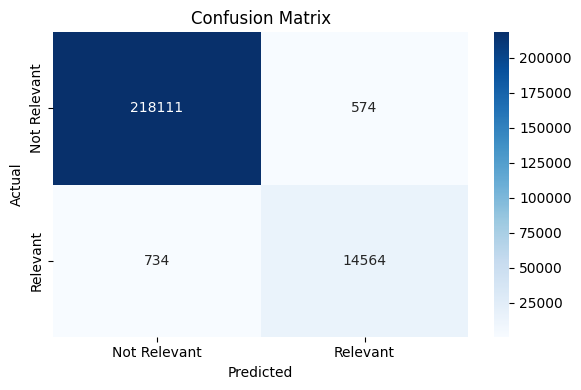

In [77]:
# Confusion Matrix Heatmap 
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Relevant", "Relevant"], yticklabels=["Not Relevant", "Relevant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

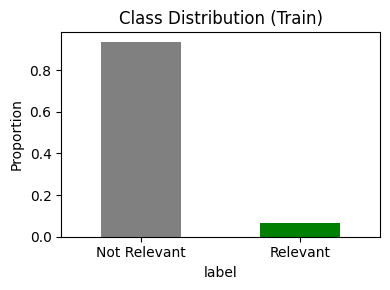

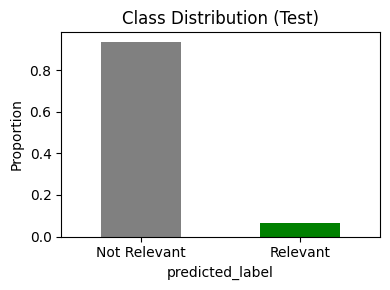

In [78]:
# Visualize the train imbalance in the data ~ Relevant vs. Non Relevant
plt.figure(figsize=(4, 3))
train_df["label"].value_counts(normalize=True).plot(kind="bar", color=["gray", "green"])
plt.title("Class Distribution (Train)")
plt.xticks(ticks=[0, 1], labels=["Not Relevant", "Relevant"], rotation=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

# Visualize the test imbalance in the data ~ Relevant vs. Non Relevant
plt.figure(figsize=(4, 3))
test_df["predicted_label"].value_counts(normalize=True).plot(kind="bar", color=["gray", "green"])
plt.title("Class Distribution (Test)")
plt.xticks(ticks=[0, 1], labels=["Not Relevant", "Relevant"], rotation=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [79]:
# Discrete proportions for each df
test_df["predicted_label"].value_counts(normalize=True)
#train_df["label"].value_counts(normalize=True)

predicted_label
0    0.935303
1    0.064697
Name: proportion, dtype: float64

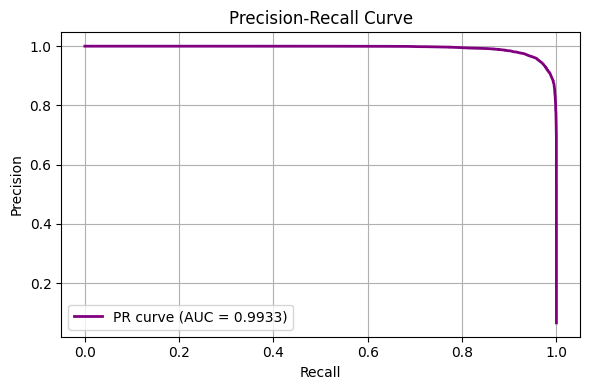

In [80]:
# Precision-Recall Curve
y_test_proba = model.predict_proba(test_df["combined_text"])[:, 1]  # Probabilities for class 1

precision, recall, thresholds = precision_recall_curve(y_test_true, y_test_proba)
pr_auc = average_precision_score(y_test_true, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.tight_layout()
plt.show()

In [81]:
# Check the Position and DepartmentOrSubdivision columns' stats here

#filtered_df.groupby('clean_city_name')['Position'].nunique().sort_values(ascending=False).head(10)
filtered_df['Position'].value_counts().head(15)

Position
Associate Planner                487
Senior Planner                   463
Assistant Engineer               355
Assistant Planner                344
Associate Engineer               339
Planning Commissioner            306
Senior Civil Engineer            267
Building Inspector               259
Assistant Engineer - Civil       216
Building Inspector II            207
Permit Technician                206
Senior Building Inspector        187
Building Mechanical Inspector    175
Principal Planner                159
Public Svc Aide-Public Works     156
Name: count, dtype: int64

In [82]:
# Cities Represented
print("Total Cities/Unincorporated Areas Represented: ", filtered_df['EmployerName'].dropna().nunique())
# Counties Represented
print("Total Counties Represented: ", filtered_df['EmployerCounty'].dropna().nunique())
# Total Positions
print("Total Positions:", filtered_df['Position'].value_counts().sum())
print("Total Unique Positions:", filtered_df['Position'].dropna().nunique())
# Departments / Subdivisions
print("Total Unique Depts:", filtered_df['DepartmentOrSubdivision'].dropna().nunique()
)

Total Cities/Unincorporated Areas Represented:  452
Total Counties Represented:  54
Total Positions: 21661
Total Unique Positions: 4094
Total Unique Depts: 570


In [83]:
missing_cities = geo_city.loc[~geo_city['has_data'], 'clean_name']
print(f"{len(missing_cities)} cities present in shapefile but missing personnel data:")
print(missing_cities.unique())

764 cities present in shapefile but missing personnel data:
['Fremont' 'Unincorporated' 'Amador City' 'Firebaugh' 'Calexico'
 'California' 'Taft' 'Bradbury' 'Glendora' 'Hidden Hills'
 'La Cañada Flintridge' 'Montebello' 'Santa Fe Springs' 'South Pasadena'
 'Novato' 'Willits' 'Del Rey Oaks' 'Fullerton' 'Banning' 'Beaumont'
 'Isleton' 'Chino' 'Rialto' 'Vista' 'Mountain House' 'Paso Robles'
 'Atherton' 'Colma' 'Redding' 'Loyalton' 'Mount Shasta' 'Waterford'
 'Yuba City' 'Tehama' 'Farmersville' 'Oxnard' 'Ventura']


In [84]:
# Most workers per city
city_counts = filtered_df['clean_city_name'].value_counts()
print("Top 5 Cities by Worker Count:\n", city_counts.head(5))

# Least workers (but drop NaNs first)
print("\nBottom 5 Cities by Worker Count:\n", city_counts[city_counts > 0].tail(5))
print("\nNAs:\n", city_counts.isna().sum())


Top 5 Cities by Worker Count:
 clean_city_name
Los Angeles      1919
San Francisco    1491
San Diego         924
San Jose          838
Oakland           540
Name: count, dtype: int64

Bottom 5 Cities by Worker Count:
 clean_city_name
Colfax       1
Sand City    1
Dos Palos    1
Maricopa     1
Trinidad     1
Name: count, dtype: int64

NAs:
 0


In [85]:
# Most workers per county
county_counts = filtered_df['clean_county_name'].value_counts()
print("Top 10 Counties by Worker Count:\n", county_counts.head(10))

# Least workers
print("\nBottom 10 Counties by Worker Count:\n", county_counts[county_counts > 0].tail(10))
print("\nNAs:\n", county_counts.isna().sum())


Top 10 Counties by Worker Count:
 clean_county_name
Los Angeles       5110
Orange            2021
Santa Clara       1700
San Diego         1557
San Francisco     1491
Alameda           1061
Riverside         1056
Contra Costa       664
San Mateo          650
San Bernardino     629
Name: count, dtype: int64

Bottom 10 Counties by Worker Count:
 clean_county_name
Tehama       13
Glenn         9
Colusa        9
Tuolumne      8
Del Norte     8
Calaveras     7
Plumas        5
Modoc         3
Inyo          3
Sutter        3
Name: count, dtype: int64

NAs:
 0


In [86]:
g = 10  # Change as needed

# Cities with < g positions
cities_under_g = city_counts[city_counts < 3]
print(f"\nNumber of cities with fewer than {g} positions: {len(cities_under_g)}")
print(cities_under_g.head(10))



Number of cities with fewer than 10 positions: 24
clean_city_name
San Joaquin      2
La Verne         2
Point Arena      2
Huron            2
Colusa           2
Ferndale         2
La Palma         2
Dorris           2
Rolling Hills    2
Laguna Woods     2
Name: count, dtype: int64


In [87]:
b = 25 # Change as needed

# Counties with < b positions
counties_under_b = county_counts[county_counts < b]
print(f"\nNumber of counties with fewer than {b} positions: {len(counties_under_b)}")
print(counties_under_b.head(10))


Number of counties with fewer than 25 positions: 15
clean_county_name
Madera       24
Mendocino    23
Mono         22
Lassen       21
Yuba         13
Tehama       13
Glenn         9
Colusa        9
Tuolumne      8
Del Norte     8
Name: count, dtype: int64


In [88]:
# Missing city name
missing_city = filtered_df['clean_city_name'].isna().sum()
print(f"Rows with missing city name: {missing_city}")

# Missing county name
missing_county = filtered_df['clean_county_name'].isna().sum()
print(f"Rows with missing county name: {missing_county}")

# Optionally: View rows
#filtered_df[filtered_df['clean_city_name'].isna() | filtered_df['clean_county_name'].isna()]


Rows with missing city name: 0
Rows with missing county name: 0


In [41]:
# View Distributions
print("City Personnel Bins Distribution")
print(agg_city_counts['city_personnel_bin'].value_counts().sort_index())

print("County Personnel Bin Distribution")
print(agg_county_counts['county_personnel_bin'].value_counts().sort_index())

City Personnel Bins Distribution
city_personnel_bin
0–100        411
100–1000      39
1000–5000      2
5000+          0
Name: count, dtype: int64
County Personnel Bin Distribution
county_personnel_bin
0–100        25
100–1000     22
1000–5000     6
5000+         1
Name: count, dtype: int64


Annual Analysis Below

In [42]:
# Load excel files and Combine into master df
# Caution ~ This will take about 25-30 minutes 

excel_files = glob.glob("City and County Raw Personnel Data/*.xlsx")

all_years = []

for file in excel_files:
    year = int(re.search(r'(\d{4})', file).group(1))
    df_year = pd.read_excel(file)
    df_year['year'] = year
    all_years.append(df_year)

#excel_files   
combined_df = pd.concat(all_years, ignore_index=True)

In [43]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7156565 entries, 0 to 7156564
Data columns (total 30 columns):
 #   Column                                Dtype         
---  ------                                -----         
 0   Year                                  int64         
 1   EmployerType                          object        
 2   EmployerName                          object        
 3   DepartmentOrSubdivision               object        
 4   Position                              object        
 5   ElectedOfficial                       bool          
 6   Judicial                              bool          
 7   OtherPositions                        object        
 8   MinPositionSalary                     float64       
 9   MaxPositionSalary                     float64       
 10  ReportedBaseWage                      float64       
 11  RegularPay                            float64       
 12  OvertimePay                           float64       
 13  LumpSumPay  

In [89]:
# Prepare text for classification
combined_df["combined_text"] = combined_df["DepartmentOrSubdivision"].fillna('') + " " + combined_df["Position"].fillna('')

# Predict relevant personnel
combined_df["predicted_label"] = model.predict(combined_df["combined_text"])

# Filter only relevant
relevant_df = combined_df[combined_df["predicted_label"] == 1]

# Clean city/county names
relevant_df['clean_city_name'] = relevant_df['EmployerName'].apply(clean_name)
relevant_df['clean_county_name'] = relevant_df['EmployerCounty'].apply(clean_name)


C:\Users\Rford\AppData\Local\Temp\ipykernel_44120\1018008930.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df['clean_city_name'] = relevant_df['EmployerName'].apply(clean_name)
C:\Users\Rford\AppData\Local\Temp\ipykernel_44120\1018008930.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df['clean_county_name'] = relevant_df['EmployerCounty'].apply(clean_name)


In [118]:
# Filter to just Los Angeles
la_city_df = relevant_df[relevant_df['clean_city_name'] == "Los Angeles"]
la_county_df = relevant_df[relevant_df['clean_county_name'] == "Los Angeles"]
la_other_cities_df = la_county_df[la_county_df['clean_city_name'] != "Los Angeles"]

In [119]:
la_county_df['Position'].value_counts().head(20)

Position
Associate Civil Engineer              2423
Civil Engineer                        2319
Building Mechanical Inspector         1718
Senior Civil Engineer                 1683
Public Works Laborer                  1610
Senior Civil Engineering Assistant    1305
Public Works Crew Leader              1265
Civil Engineering Associate II        1151
Planning Assistant                    1130
Associate Planner                     1005
City Planner                           938
Civil Engineering Associate I          817
Civil Engineering Assistant            807
Building Inspector                     787
Principal Civil Engineering Asst       762
Assistant Planner                      745
City Planning Associate                737
Senior Planner                         683
Senior Building Inspector              613
Civil Engineering Associate III        574
Name: count, dtype: int64

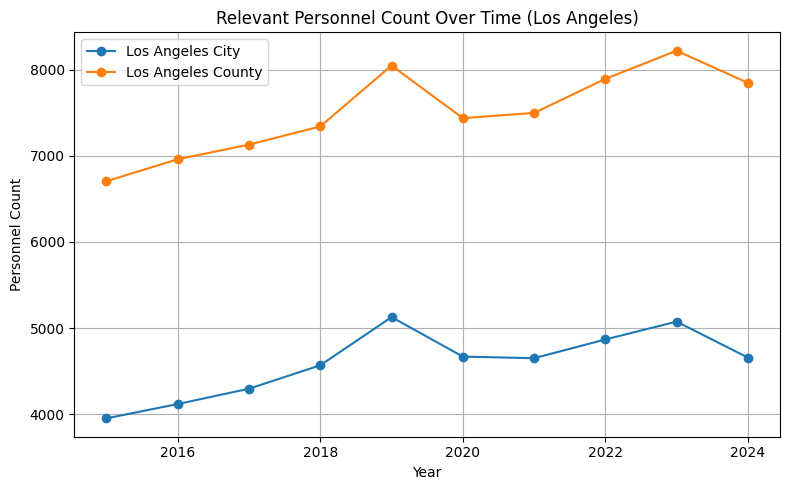

In [120]:
# Plot relevant personnel count
la_city_counts = la_city_df.groupby('Year').size().reset_index(name='personnel_count_city')
la_county_counts = la_county_df.groupby('Year').size().reset_index(name='personnel_count_county')

plt.figure(figsize=(8, 5))
plt.plot(la_city_counts['Year'], la_city_counts['personnel_count_city'], marker='o', label='Los Angeles City')
plt.plot(la_county_counts['Year'], la_county_counts['personnel_count_county'], marker='o', label='Los Angeles County')
plt.title("Relevant Personnel Count Over Time (Los Angeles)")
plt.xlabel("Year")
plt.ylabel("Personnel Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


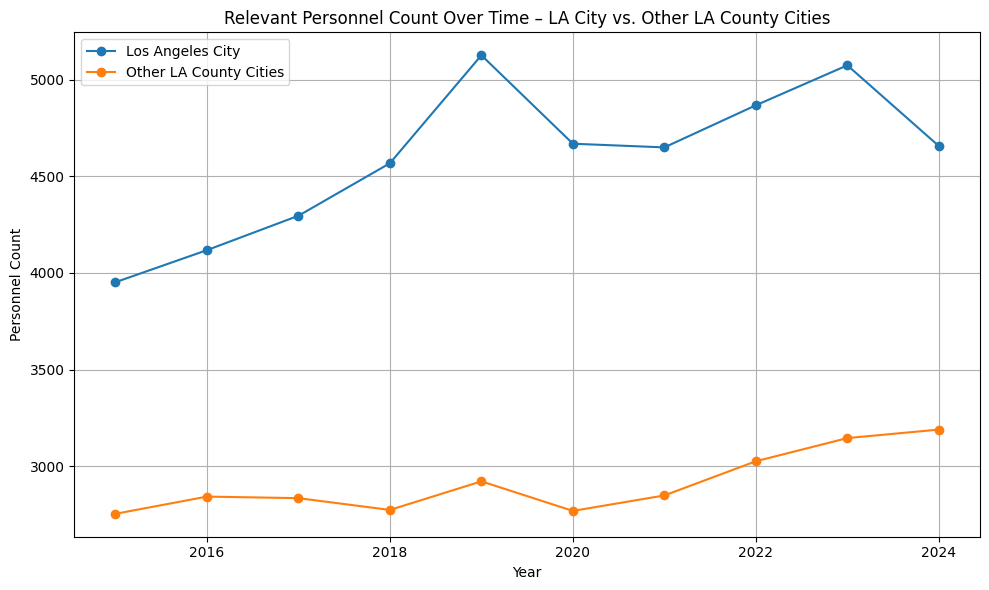

In [121]:
# Plot relevant personnel count
la_city_counts = la_city_df.groupby('Year').size().reset_index(name='personnel_count_city')
la_other_counts = la_other_cities_df.groupby('Year').size().reset_index(name='personnel_count_other_cities')

# Merge to ensure aligned years
merged = pd.merge(
    la_city_counts,
    la_other_counts,
    on='Year',
    how='outer'
).fillna(0).sort_values('Year')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(merged['Year'], merged['personnel_count_city'], marker='o', label='Los Angeles City')
plt.plot(merged['Year'], merged['personnel_count_other_cities'], marker='o', label='Other LA County Cities')
plt.title("Relevant Personnel Count Over Time – LA City vs. Other LA County Cities")
plt.xlabel("Year")
plt.ylabel("Personnel Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Rford\AppData\Local\Temp\ipykernel_44120\2918260300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_la_positions.index, x=top_la_positions.values, palette="Blues_d")


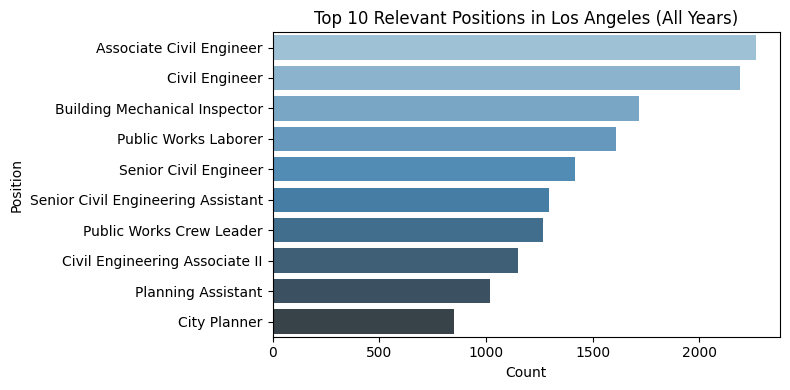

In [122]:
# La Bar chart
top_la_positions = la_city_df['Position'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(y=top_la_positions.index, x=top_la_positions.values, palette="Blues_d")
plt.title("Top 10 Relevant Positions in Los Angeles (All Years)")
plt.xlabel("Count")
plt.ylabel("Position")
plt.tight_layout()
plt.show()


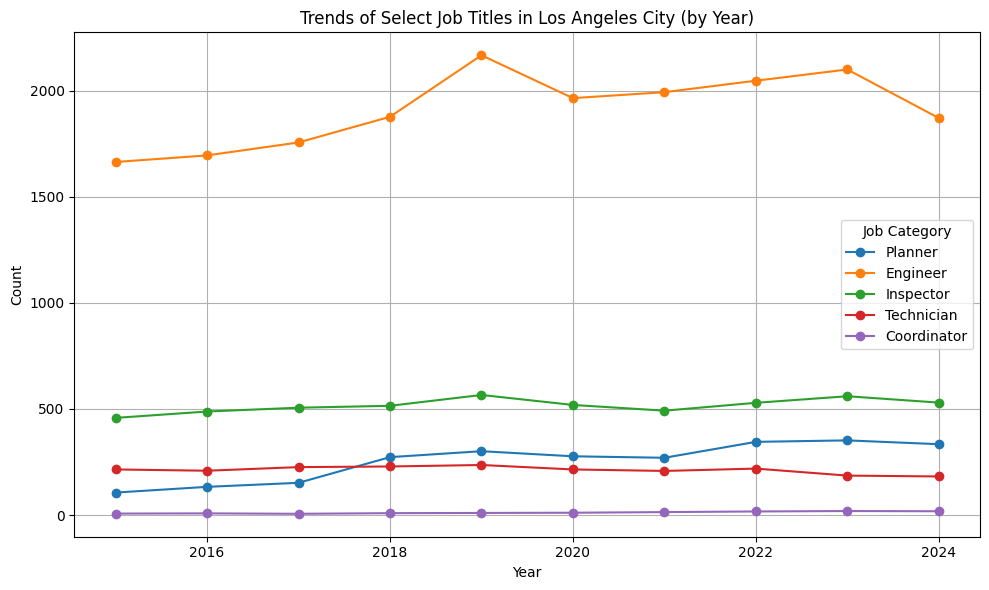

In [47]:
# Trends
# Define job categories (simplified)
job_keywords = ['Planner', 'Engineer', 'Inspector', 'Technician', 'Coordinator']

# Extract and count per year
job_trends = {}

for keyword in job_keywords:
    mask = la_city_df['Position'].str.contains(keyword, case=False, na=False)
    counts = la_city_df[mask].groupby('Year').size()
    job_trends[keyword] = counts

# Convert to DataFrame
job_trends_df = pd.DataFrame(job_trends).fillna(0)

# Plot
job_trends_df.plot(kind='line', marker='o', figsize=(10, 6))
plt.title("Trends of Select Job Titles in Los Angeles City (by Year)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Job Category")
plt.grid(True)
plt.tight_layout()
plt.show()
